In [37]:
import sys
import os
from pathlib import Path

current_dir = Path.cwd()
repo_root = current_dir.parent if (current_dir / 'scripts').exists() == False else current_dir
scripts_path = repo_root / 'scripts'

if str(scripts_path) not in sys.path:
    sys.path.append(str(scripts_path))

import importlib
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
from plot_style import apply
apply()

import cross_sectional_estimation as cse
importlib.reload(cse) # Re-run estimation with the new portable logic

# ---------------------------------------------------------
# NEW: Filter the dataset for specific stocks before estimation
# ---------------------------------------------------------

# 1. Read the specific stocks you want to estimate
stocks_csv_path = Path(r"C:\Users\jonat\Lasso_paper\Empirical\estimation\estim_stocks.csv")
target_stocks_df = pd.read_csv(stocks_csv_path)

# Ensure stocks are treated as strings to match the column names in the returns dataframe
target_stocks = target_stocks_df['stock'].astype(str).tolist()

# 2. Load the original, full returns data
original_returns_path = cse.REPO_ROOT / "Data" / "data_raw" / "cross_sectional_returns.csv"
full_returns_df = pd.read_csv(original_returns_path, index_col=0)

# 3. Filter for the columns that actually exist in the main dataset
valid_stocks = [s for s in target_stocks if s in full_returns_df.columns]
filtered_returns_df = full_returns_df[valid_stocks]

print(f"Loaded {len(target_stocks)} target stocks. Found {len(valid_stocks)} in the returns dataset.")

# 4. Save to a temporary CSV to feed into the estimation script
filtered_returns_path = cse.REPO_ROOT / "Data" / "data_raw" / "filtered_estim_returns.csv"
filtered_returns_df.to_csv(filtered_returns_path)

# ---------------------------------------------------------
# END NEW LOGIC
# ---------------------------------------------------------

out = cse.main(
    returns_csv = filtered_returns_path,  # Feed the filtered dataset here
    out_dir = cse.REPO_ROOT / "Results" / "Estimation" / "Cross_Sectional",
    subset_start = 0,
    subset_end = -1,
    n_jobs = -1,
    save = True
)

Loaded 1296 target stocks. Found 1296 in the returns dataset.
--- Debug Output ---
Load Returns from: C:\Users\jonat\Lasso_paper\Data\data_raw\filtered_estim_returns.csv
Initial Returns Shape: (1889, 1296)
Load Features from: C:\Users\jonat\Lasso_paper\Data\clean_data\final_macro_topic_features.csv
Initial Features Shape: (2921, 190)

Data Alignment check:
Features Date Range: 2006-01-04 00:00:00 to 2017-06-30 00:00:00
Returns Date Range:  2010-01-04 00:00:00 to 2017-06-30 00:00:00
Overlapping Dates Found: 1888

Hyperparameters loaded: Window=231, Lags=1, Lambda=0.003505898780188227
Selecting subset [0:1296] -> Total 1296 stocks to evaluate.
--------------------



Estimating per stock:   0%|          | 0/1296 [00:00<?, ?it/s]


--- Estimation Report ---
Total stocks attempted: 1296
Successful: 1296
Failed: 0
-------------------------

Saved beta tensor  → C:\Users\jonat\Lasso_paper\Results\Estimation\Cross_Sectional\betas.h5  (1296, 190, 1657)  (1.63 GB uncompressed)
Saved summary      → C:\Users\jonat\Lasso_paper\Results\Estimation\Cross_Sectional\summary.csv


In [38]:
OUT_DIR = cse.REPO_ROOT / "Results" / "Estimation" / "Cross_Sectional"

# ── Load tensor and coordinates ──────────────────────────────────────────────
with h5py.File(os.path.join(OUT_DIR, 'betas.h5'), 'r') as f:
    betas  = f['betas'][:]               # (n_stocks, n_topics, n_dates) float32
    stocks = f['stocks'][:].astype(str)
    topics = f['topics'][:].astype(str)
    dates  = pd.to_datetime(f['dates'][:].astype(str))

summary_df = pd.read_csv(os.path.join(OUT_DIR, 'summary.csv'), index_col=0)
summary_df.index = summary_df.index.astype(str)

# ── Derived quantities ───────────────────────────────────────────────────────
# NaN entries mean the stock had no data at that date; treat as not selected
betas_nz = np.nan_to_num(betas, nan=0.0)
sel      = betas_nz != 0                 # (n_stocks, n_topics, n_dates) bool

has_data     = np.isfinite(betas).any(axis=1)                      # (n_stocks, n_dates)
n_valid_days = has_data.sum(axis=1, keepdims=True).astype(float)   # (n_stocks, 1)

# Selection frequency per (stock, topic): fraction of valid days topic was selected
sel_mat = sel.sum(axis=2) / np.maximum(n_valid_days, 1)  # (n_stocks, n_topics)

# Active topics per (stock, date) — NaN where stock has no data
active_per_day = sel.sum(axis=1).astype(float)   # (n_stocks, n_dates)
active_per_day[~has_data] = np.nan

# Per-stock mean active topics over time
mean_num_active = np.nanmean(active_per_day, axis=1)  # (n_stocks,)
summary_df['mean_num_active'] = pd.Series(mean_num_active, index=stocks)

# Per-topic average selection frequency across all stocks
topic_avg_series = (
    pd.Series(sel_mat.mean(axis=0), index=topics)
    .sort_values(ascending=False)
)

# Filtered selection matrix: only non-failed stocks (at least one selection)
valid_mask = mean_num_active > 0
sel_mat_df = pd.DataFrame(sel_mat[valid_mask], index=stocks[valid_mask], columns=topics)
mean_sel   = sel_mat_df.mean()   # per-topic avg across non-failed stocks

print(f'Tensor  : {betas.shape}')
print(f'Stocks  : {len(stocks)}  ({valid_mask.sum()} non-failed)')
print(f'Topics  : {len(topics)}')
print(f'Dates   : {len(dates)}  ({dates[0].date()} \u2192 {dates[-1].date()})')
summary_df.head()

Tensor  : (1296, 190, 1657)
Stocks  : 1296  (1117 non-failed)
Topics  : 190
Dates   : 1657  (2010-12-02 → 2017-06-30)


,window_size,n_lags,lambda,r2_insample_stage1,r2_oos_stage1,r2_insample_stage2,r2_oos_stage2,kappa,kappa_tstat,intercept,intercept_tstat,n_observations,n_windows,n_oos_predictions_stage2,avg_selection_rate,return_variance,mean_num_active
stock,,,,,,,,,,,,,,,,,
90444,231,1,0.003506,0.009530,-0.002237,-6.746715e-09,-0.005319,3.134290e-06,0.000010,0.000475,1.024078,1651,1654,NaN,0.009948,0.000354,1.890163
81540,231,1,0.003506,-0.006326,-0.002894,-4.268184e-08,-0.000613,6.979772e-03,0.001707,0.000726,2.245744,1651,1654,NaN,0.000286,0.000177,0.054315
70519,231,1,0.003506,0.026366,-0.007956,7.947252e-05,-0.011069,4.573448e-02,0.377952,0.000229,0.455004,1651,1654,NaN,0.019614,0.000441,3.726614
90825,231,1,0.003506,0.063327,-0.017971,1.904555e-04,-0.002493,5.969461e-02,0.596142,0.000200,0.301243,1651,1654,NaN,0.047009,0.000824,8.931804
83976,231,1,0.003506,0.085183,-0.034071,-1.038755e-08,-0.005698,5.755219e-07,0.000005,-0.000795,-1.080351,1651,1654,NaN,0.059130,0.000888,11.234762


In [39]:
import numpy as np
import pandas as pd

def generate_latex_summary_table(df, columns, row_labels, caption, label, note_text):
    """
    Generates a LaTeX table with summary statistics for specified columns.
    """
    # Calculate statistics
    stats = []
    for col in columns:
        s = df[col].dropna()
        stats.append({
            'mean': s.mean(),
            'std': s.std(),
            'median': s.median(),
            'min': s.min(),
            'max': s.max(),
            'p05': s.quantile(0.05),
            'p95': s.quantile(0.95)
        })
    
    stats_df = pd.DataFrame(stats, index=row_labels)
    
    # Format the LaTeX output
    latex_str = f"\\begin{{table}}[H]\n\\centering\n\\caption{{{caption}}}\n\\label{{{label}}}\n"
    latex_str += "\\begin{tabularx}{\\textwidth}{@{}Xccccccc@{}}\n\\toprule\n"
    latex_str += " & mean & std & median & min & max & p05 & p95 \\\\\n\\midrule\n"
    
    for idx, row in stats_df.iterrows():
        latex_str += f"{idx} & {row['mean']:.4f} & {row['std']:.4f} & {row['median']:.4f} & "
        latex_str += f"{row['min']:.4f} & {row['max']:.4f} & {row['p05']:.4f} & {row['p95']:.4f} \\\\\n"
        
    latex_str += "\\bottomrule\n\\end{tabularx}\n\\medskip\n\\begin{minipage}{\\textwidth}\n\\footnotesize\n"
    latex_str += f"\\textit{{Note:}} {note_text}\n\\end{{minipage}}\n\\end{{table}}\n"
    
    return latex_str

# ---------------------------------------------------------
# Data Filtering
# ---------------------------------------------------------
# Filter out any failed estimation stocks if needed
stage1_df = summary_df.dropna(subset=['r2_insample_stage1', 'avg_selection_rate'])

# Filter stocks with non-zero selection rate
non_zero_df = stage1_df[stage1_df['avg_selection_rate'] > 0]

# Filter for significant kappa (t-stat > 1.96 or < -1.96)
sig_kappa_df = non_zero_df[(non_zero_df['kappa_tstat'] > 1.96) | (non_zero_df['kappa_tstat'] < -1.96)]

# Calculate counts for notes dynamically
n_total = len(stage1_df)
n_nonzero = len(non_zero_df)
n_sig = len(sig_kappa_df)
pct_sig = (n_sig / n_nonzero) * 100 if n_nonzero > 0 else 0

lambda_val = stage1_df['lambda'].iloc[0] if not stage1_df['lambda'].isna().all() else "N/A"
window_val = int(stage1_df['window_size'].iloc[0])
lags_val = int(stage1_df['n_lags'].iloc[0])

# ---------------------------------------------------------
# Table 1: First-Stage LASSO Estimation Results (Sig Kappa Only)
# ---------------------------------------------------------
note_stage1 = (
    f"The table reports summary statistics across the {n_sig} estimation stocks for which "
    "$\\hat{\\kappa}$ is statistically significant at the 5\\% level, for the first-stage LASSO "
    "in-sample $R^2$, computed within each rolling window and averaged over windows, "
    "the first-stage out-of-sample $R^2$, computed from the sequence of one-step-ahead LASSO forecasts "
    "evaluated against realised (demeaned) returns with the zero-forecast as benchmark, "
    "and the average LASSO selection rate (fraction of predictor-window cells with a non-zero coefficient). "
    f"Calibrated parameters: $\\lambda^* = {lambda_val:.3e}$, $s^* = {window_val}$ days, $n = {lags_val}$ lag."
)

# Pass sig_kappa_df here instead of stage1_df
latex_table_1 = generate_latex_summary_table(
    df=sig_kappa_df,
    columns=['r2_insample_stage1', 'r2_oos_stage1', 'avg_selection_rate'],
    row_labels=['In-sample $R^2$', 'Out-of-sample $R^2$', 'Selection rate'],
    caption="Summary Statistics of LASSO Estimation Results",
    label="tab:summary_stats_lasso",
    note_text=note_stage1
)

# ---------------------------------------------------------
# Table 3: Second-Stage Estimation Results (Significant Kappa)
# ---------------------------------------------------------
note_stage2 = (
    f"The table reports summary statistics across the {n_sig} estimation stocks "
    f"({pct_sig:.1f}\\% of the {n_nonzero} with non-zero LASSO selection) for which $\\hat{{\\kappa}}$ is statistically "
    "significant at the 5\\% level. "
    "In-sample $R^2$ is the second-stage NLS fit evaluated on the full time series. "
    "$\\hat{\\kappa}$ is the estimated belief-feedback parameter and its $t$-statistic is computed "
    "from the NLS sandwich standard error."
)

latex_table_3 = generate_latex_summary_table(
    df=sig_kappa_df,
    columns=['r2_insample_stage2', 'kappa', 'kappa_tstat'],
    row_labels=['In-sample $R^2$', '$\\hat{\\kappa}$', '$t$-statistic of $\\hat{\\kappa}$'],
    caption="Second-Stage Estimation: Summary Statistics",
    label="tab:summary_stats_stage2",
    note_text=note_stage2
)

# Print the results
print("% " + "="*50)
print("% Table 1: LASSO Summary Stats")
print("% " + "="*50)
print(latex_table_1)
print("\n")
print("% " + "="*50)
print("% Table 3: Stage 2 NLS Summary Stats")
print("% " + "="*50)
print(latex_table_3)

% ==================================================
% Table 1: LASSO Summary Stats
% ==================================================
\begin{table}[H]
\centering
\caption{Summary Statistics of LASSO Estimation Results}
\label{tab:summary_stats_lasso}
\begin{tabularx}{\textwidth}{@{}Xccccccc@{}}
\toprule
 & mean & std & median & min & max & p05 & p95 \\
\midrule
In-sample $R^2$ & 0.0255 & 0.0408 & 0.0094 & -0.0057 & 0.2297 & -0.0036 & 0.0960 \\
Out-of-sample $R^2$ & -0.0081 & 0.0239 & -0.0010 & -0.1243 & 0.0163 & -0.0567 & 0.0053 \\
Selection rate & 0.0200 & 0.0309 & 0.0061 & 0.0000 & 0.1775 & 0.0000 & 0.0701 \\
\bottomrule
\end{tabularx}
\medskip
\begin{minipage}{\textwidth}
\footnotesize
\textit{Note:} The table reports summary statistics across the 111 estimation stocks for which $\hat{\kappa}$ is statistically significant at the 5\% level, for the first-stage LASSO in-sample $R^2$, computed within each rolling window and averaged over windows, the first-stage out-of-sample $R^2$,

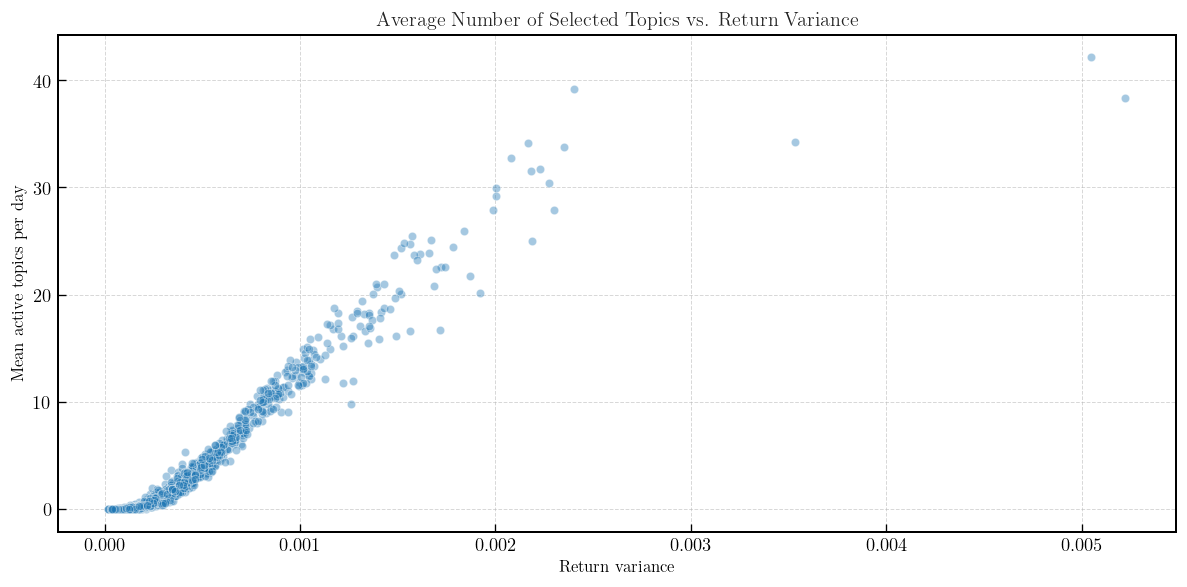

In [40]:
# 1. Setup the figure to match the 10x5 aspect ratio
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Filter data
plot_df = summary_df[['return_variance', 'mean_num_active']].dropna()

# 3. Plot with matching colors (tab:blue) and adjusted styling
sns.scatterplot(
    data=plot_df, 
    x='return_variance', 
    y='mean_num_active', 
    ax=ax, 
    color='tab:blue',  # Matches the line color of the first plot
    alpha=0.4,         # Slightly more transparent for dense clusters
    s=25,              # Marker size
    edgecolor='w',     # White edge to help distinguish overlapping points
    linewidth=0.5
)

# 4. Align text styles and labels
ax.set_title('Average Number of Selected Topics vs. Return Variance', fontsize=12)
ax.set_xlabel('Return variance', fontsize=10)
ax.set_ylabel('Mean active topics per day', fontsize=10)

# Optional: Add a light grid to match the professional "paper" feel
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Handle layout and saving
plt.tight_layout()

# Define path using your pathlib setup
results_dir = cse.REPO_ROOT / "Results" / "Estimation" / "Cross_Sectional"
results_dir.mkdir(parents=True, exist_ok=True)
file_path = results_dir / "scatter_variance_vs_active.png"

plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

In [41]:
results_dir = cse.REPO_ROOT / "Results" / "Estimation" / "Cross_Sectional"
h5_path = results_dir / "betas.h5"

# Load the HDF5 tensor
with h5py.File(h5_path, "r") as f:
    betas = f["betas"][:] # shape: (n_stocks, n_topics, n_dates)
    dates_raw = f["dates"][:].astype(str)
    stocks = f["stocks"][:].astype(str)
    topics = f["topics"][:].astype(str)

dates = pd.to_datetime(dates_raw)

# A predictor is selected (active) if its coefficient is not exactly zero and not NaN
is_valid = ~np.isnan(betas)
is_active = (betas != 0) & is_valid

# Count active predictors per stock per date. 
# If a stock has no valid estimation on a given date, we set it to NaN.
valid_stock_date = is_valid.any(axis=1)
active_per_stock_date = np.where(valid_stock_date, is_active.sum(axis=1), np.nan)

# Define plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

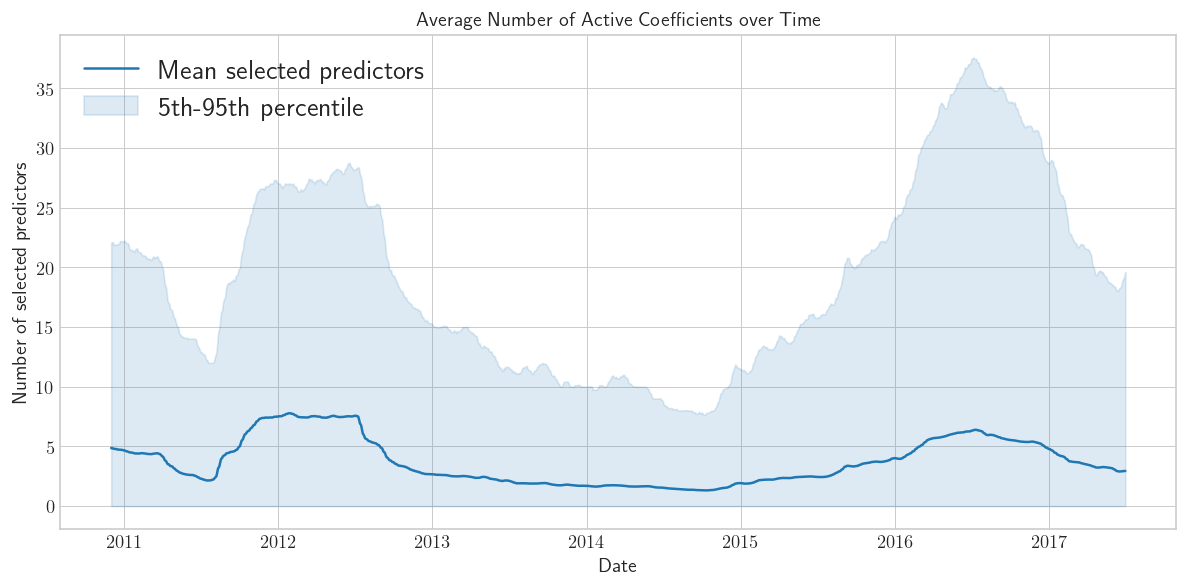

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

# Calculate cross-sectional statistics for each date
mean_selected = np.nanmean(active_per_stock_date, axis=0)
p05_selected = np.nanpercentile(active_per_stock_date, 5, axis=0)
p95_selected = np.nanpercentile(active_per_stock_date, 95, axis=0)

# Apply a 10-day moving average for smoother plotting, matching the paper's style
mean_smooth = pd.Series(mean_selected).rolling(window=10, min_periods=1).mean()
p05_smooth = pd.Series(p05_selected).rolling(window=10, min_periods=1).mean()
p95_smooth = pd.Series(p95_selected).rolling(window=10, min_periods=1).mean()

ax.plot(dates, mean_smooth, label='Mean selected predictors', color='tab:blue', linewidth=1.5)
ax.fill_between(dates, p05_smooth, p95_smooth, color='tab:blue', alpha=0.15, label='5th-95th percentile')

ax.set_title('Average Number of Active Coefficients over Time', fontsize=12)
ax.set_ylabel('Number of selected predictors')
ax.set_xlabel('Date')
ax.legend(loc='upper left')

plt.tight_layout()
file_path = results_dir / "active_coefficients_over_time.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\%'
<>:64: SyntaxWarning: invalid escape sequence '\%'
<>:45: SyntaxWarning: invalid escape sequence '\%'
<>:64: SyntaxWarning: invalid escape sequence '\%'
C:\Users\jonat\AppData\Local\Temp\ipykernel_53796\1625091517.py:45: SyntaxWarning: invalid escape sequence '\%'
  ax1.set_ylabel('Mean selection rate (\%)')
C:\Users\jonat\AppData\Local\Temp\ipykernel_53796\1625091517.py:64: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_xlabel('Mean selection rate (\%)')


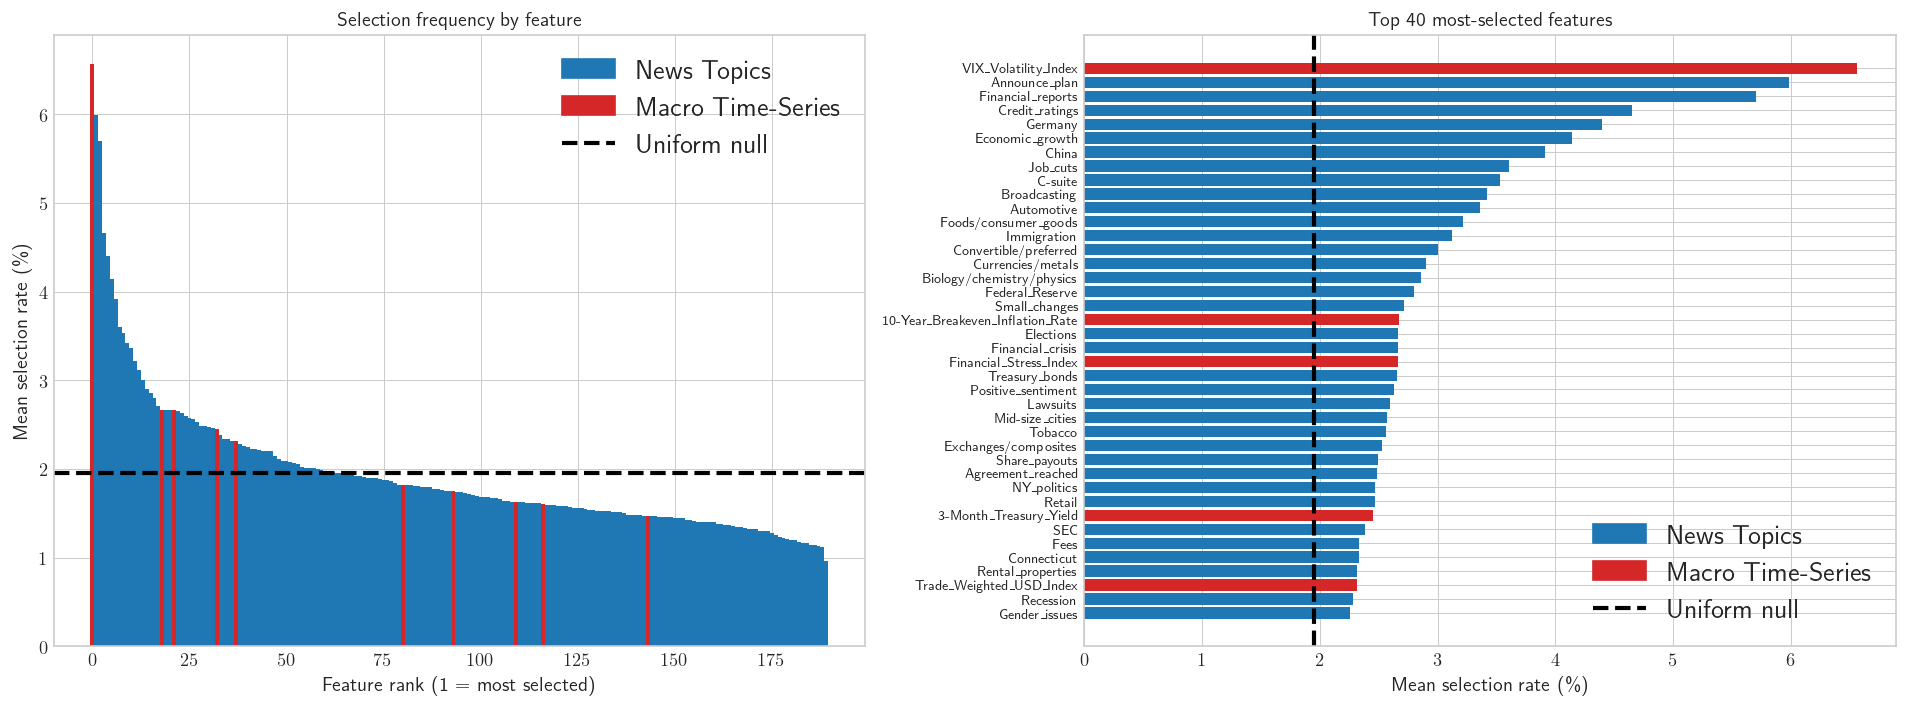

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define your macro features from the series_map
series_map = {
    'DFF': 'Fed Funds Effective Rate',
    'DGS10': '10-Year Treasury Yield',
    'VIXCLS': 'VIX Volatility Index',
    'STLFSI4': 'Financial Stress Index',
    'BAMLH0A0HYM2': 'High Yield Option-Adjusted Spread',
    'DTWEXBGS': 'Trade Weighted USD Index',
    'DGS3MO': '3-Month Treasury Yield',
    'DCOILWTICO': 'WTI Crude Oil',
    'T10YIE': '10-Year Breakeven Inflation Rate',
    'DEXJPUS': 'USD to JPY',
}
macro_names = [name.replace(' ', '_') for name in series_map.values()]
# Calculate selection rate per feature across all valid stock-window cells
active_cells_per_topic = is_active.sum(axis=(0, 2))
valid_cells_per_topic = is_valid.sum(axis=(0, 2))

# Avoid division by zero
with np.errstate(invalid='ignore'):
    selection_rate = (active_cells_per_topic / valid_cells_per_topic) * 100

# Sort topics by their selection rate
sorted_indices = np.argsort(selection_rate)[::-1]
sorted_rates = selection_rate[sorted_indices]
sorted_topics = topics[sorted_indices]

# Uniform null hypothesis line
uniform_null = (active_cells_per_topic.sum() / valid_cells_per_topic.sum()) * 100

# Create a color array for the sorted topics: red for macro, blue for news
colors = ['tab:red' if topic in macro_names else 'tab:blue' for topic in sorted_topics]

# Panel 1: All features ranked
ax1.bar(range(len(sorted_rates)), sorted_rates, color=colors, width=1.0)
ax1.axhline(uniform_null, color='black', linestyle='--', label='Uniform null')
ax1.set_title('Selection frequency by feature')
ax1.set_xlabel('Feature rank (1 = most selected)')
ax1.set_ylabel('Mean selection rate (\%)')

# Create custom legend for clarity
blue_patch = mpatches.Patch(color='tab:blue', label='News Topics')
red_patch = mpatches.Patch(color='tab:red', label='Macro Time-Series')
null_line = plt.Line2D([0], [0], color='black', linestyle='--', label='Uniform null')
ax1.legend(handles=[blue_patch, red_patch, null_line])

# Panel 2: Top 40 features
top_n = 40
y_pos = np.arange(top_n)
colors_top_n = colors[:top_n]

ax2.barh(y_pos, sorted_rates[:top_n], align='center', color=colors_top_n)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(sorted_topics[:top_n], fontsize=8)
ax2.invert_yaxis()  # Most selected at the top
ax2.axvline(uniform_null, color='black', linestyle='--', label='Uniform null')
ax2.set_title(f'Top {top_n} most-selected features')
ax2.set_xlabel('Mean selection rate (\%)')
ax2.legend(handles=[blue_patch, red_patch, null_line])

plt.tight_layout()

file_path = results_dir / "selection_frequency.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

C:\Users\jonat\AppData\Local\Temp\ipykernel_53796\511435426.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


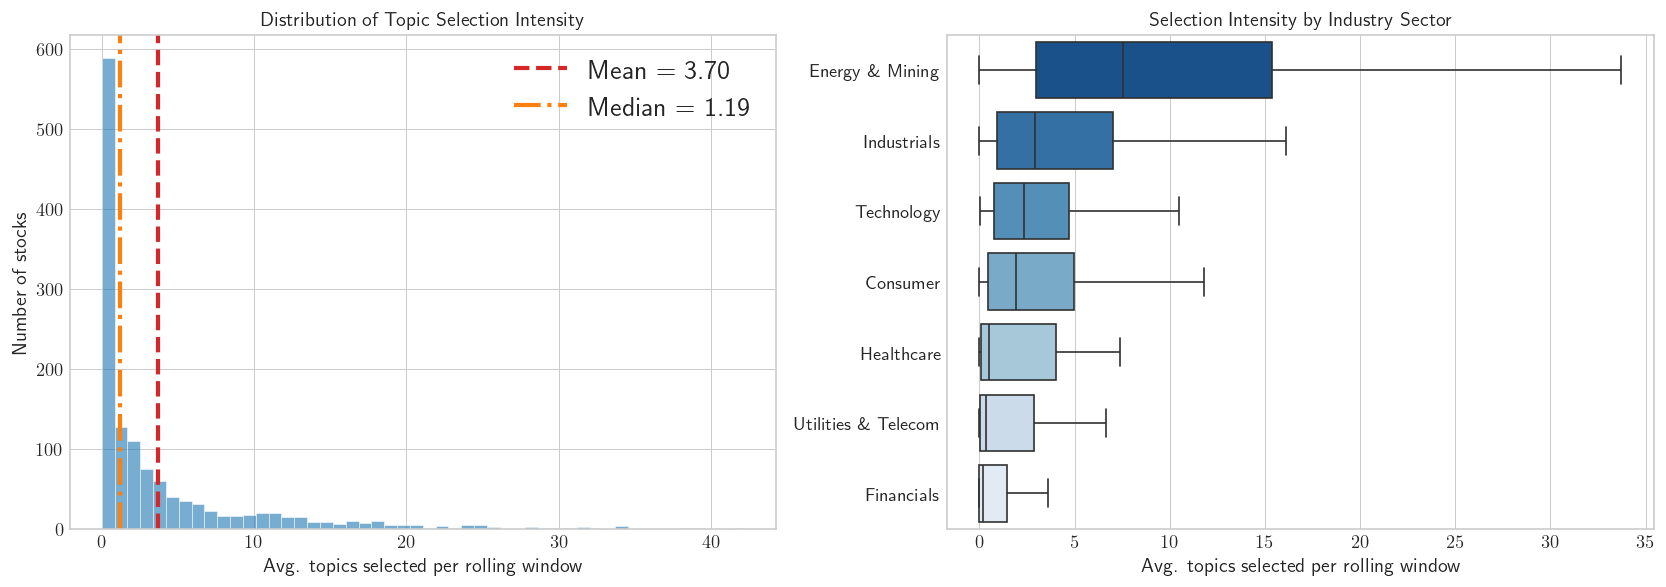

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -------------------------------------------------------------------------
# 1. Extract PERMNOs and Prepare the Data
# -------------------------------------------------------------------------
avg_topics_per_stock = np.nanmean(active_per_stock_date, axis=1)

# Extract PERMNOs from summary_df
if 'PERMNO' in summary_df.columns:
    stock_permnos = summary_df['PERMNO'].values
elif 'permno' in summary_df.columns:
    stock_permnos = summary_df['permno'].values
else:
    stock_permnos = summary_df.index.values

stock_permnos = np.array(stock_permnos, dtype=int)

df_plot = pd.DataFrame({
    'PERMNO': stock_permnos,
    'avg_topics': avg_topics_per_stock
}).dropna(subset=['avg_topics'])

# -------------------------------------------------------------------------
# 2. Map Industry Codes (WITH LATEX ESCAPES)
# -------------------------------------------------------------------------
industry_file = r"C:\Users\jonat\Lasso_paper\Data\data_raw\industry_codes.csv"
ind_df = pd.read_csv(industry_file)

def map_sic_to_sector(sic):
    if pd.isna(sic): return 'Other'
    sic = int(sic)
    # Note the use of r'...' and backslashes for LaTeX compatibility
    if (1000 <= sic <= 1499) or (2900 <= sic <= 2999): return r'Energy \& Mining'
    elif 6000 <= sic <= 6799: return 'Financials'
    elif (3570 <= sic <= 3579) or (3660 <= sic <= 3699) or (7370 <= sic <= 7379): return 'Technology'
    elif (2830 <= sic <= 2839) or (3840 <= sic <= 3859) or (8000 <= sic <= 8099): return 'Healthcare'
    elif (4800 <= sic <= 4899) or (4900 <= sic <= 4999): return r'Utilities \& Telecom'
    elif (1500 <= sic <= 1799) or (2400 <= sic <= 2499) or (2600 <= sic <= 2699) or \
         (2800 <= sic <= 2829) or (2840 <= sic <= 2899) or (3000 <= sic <= 3569) or \
         (3580 <= sic <= 3659) or (3700 <= sic <= 3799) or (3810 <= sic <= 3839) or \
         (3860 <= sic <= 3899) or (4000 <= sic <= 4799): return 'Industrials'
    elif (2000 <= sic <= 2399) or (2500 <= sic <= 2599) or (2700 <= sic <= 2799) or \
         (3100 <= sic <= 3199) or (3900 <= sic <= 3999) or (5000 <= sic <= 5999) or \
         (7000 <= sic <= 7299) or (7800 <= sic <= 7999): return 'Consumer'
    else: return 'Other'

ind_df['Sector'] = ind_df['HSICCD'].apply(map_sic_to_sector)
merged_df = pd.merge(df_plot, ind_df[['PERMNO', 'Sector']], on='PERMNO', how='left')
merged_df = merged_df[merged_df['Sector'] != 'Other']

# -------------------------------------------------------------------------
# 3. Plot the Figure
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left Panel: Histogram
mean_val = df_plot['avg_topics'].mean()
median_val = df_plot['avg_topics'].median()

ax1.hist(df_plot['avg_topics'], bins=50, alpha=0.6, color='tab:blue', edgecolor='white', linewidth=0.5)
ax1.axvline(mean_val, color='tab:red', linestyle='--', label=f'Mean = {mean_val:.2f}')
ax1.axvline(median_val, color='tab:orange', linestyle='-.', label=f'Median = {median_val:.2f}')
ax1.set_title('Distribution of Topic Selection Intensity')
ax1.set_xlabel('Avg. topics selected per rolling window')
ax1.set_ylabel('Number of stocks')
ax1.legend()

# Right Panel: Box Plots
sector_order = merged_df.groupby('Sector')['avg_topics'].median().sort_values(ascending=False).index

sns.boxplot(
    x='avg_topics', 
    y='Sector', 
    data=merged_df, 
    ax=ax2, 
    order=sector_order,
    palette='Blues_r',
    showfliers=False 
)

ax2.set_title('Selection Intensity by Industry Sector')
ax2.set_xlabel('Avg. topics selected per rolling window')
ax2.set_ylabel('')

plt.tight_layout() # This will now work without the LaTeX error

file_path = results_dir / "selection_intensity.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
C:\Users\jonat\AppData\Local\Temp\ipykernel_53796\3643797720.py:46: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_ylabel('Aggregate selection rate (\%)', color=color1)
C:\Users\jonat\AppData\Local\Temp\ipykernel_53796\3643797720.py:51: SyntaxWarning: invalid escape sequence '\%'
  ax2_twin.set_ylabel('\% stocks with zero selection', color=color2)


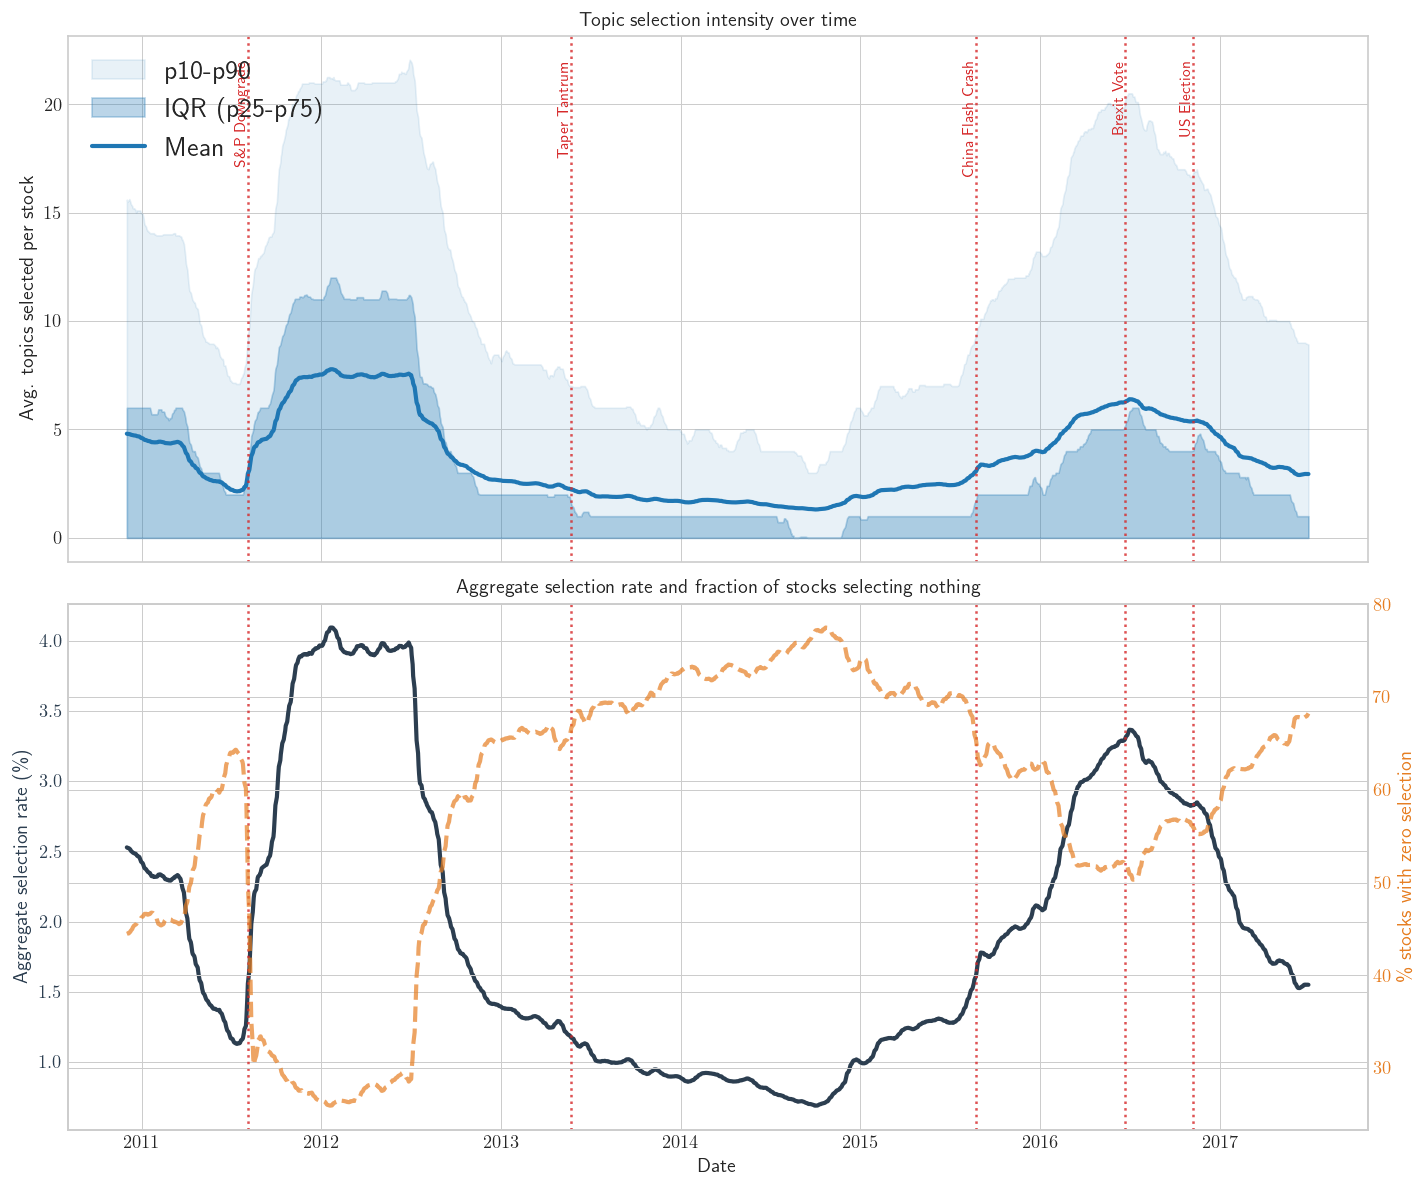

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the events
# Define the events with LaTeX-safe ampersands
events = [
    (pd.Timestamp('2011-08-05'), r'S\&P Downgrade'),  # Note the backslash and 'r' prefix
    (pd.Timestamp('2013-05-22'), 'Taper Tantrum'),
    (pd.Timestamp('2015-08-24'), 'China Flash Crash'),
    (pd.Timestamp('2016-06-23'), 'Brexit Vote'),
    (pd.Timestamp('2016-11-08'), 'US Election')
]

# ... rest of your plotting code ...

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Helper function for the 10-day centered moving average
def smooth(series):
    return pd.Series(series).rolling(window=10, center=True, min_periods=1).mean()

# --- Top Panel: Cross-sectional distribution ---
mean_sel = smooth(np.nanmean(active_per_stock_date, axis=0))
p10_sel = smooth(np.nanpercentile(active_per_stock_date, 10, axis=0))
p25_sel = smooth(np.nanpercentile(active_per_stock_date, 25, axis=0))
p75_sel = smooth(np.nanpercentile(active_per_stock_date, 75, axis=0))
p90_sel = smooth(np.nanpercentile(active_per_stock_date, 90, axis=0))

ax1.fill_between(dates, p10_sel, p90_sel, color='tab:blue', alpha=0.1, label='p10-p90')
ax1.fill_between(dates, p25_sel, p75_sel, color='tab:blue', alpha=0.3, label='IQR (p25-p75)')
ax1.plot(dates, mean_sel, color='tab:blue', label='Mean')
ax1.set_ylabel('Avg. topics selected per stock')
ax1.set_title('Topic selection intensity over time')
ax1.legend(loc='upper left')

# --- Bottom Panel: Aggregate rates ---
total_active = np.nansum(active_per_stock_date, axis=0)
total_valid_cells = np.sum(valid_stock_date, axis=0) * len(topics)
agg_selection_rate = smooth((total_active / total_valid_cells) * 100)
frac_zero_stocks = smooth(np.nanmean(active_per_stock_date == 0, axis=0) * 100)

color1, color2 = '#2C3E50', '#E67E22'

ax2.plot(dates, agg_selection_rate, color=color1)
ax2.set_ylabel('Aggregate selection rate (\%)', color=color1)
ax2.tick_params(axis='y', labelcolor=color1)

ax2_twin = ax2.twinx()
ax2_twin.plot(dates, frac_zero_stocks, color=color2, linestyle='--', alpha=0.7)
ax2_twin.set_ylabel('\% stocks with zero selection', color=color2)
ax2_twin.tick_params(axis='y', labelcolor=color2)

ax2.set_xlabel('Date')
ax2.set_title('Aggregate selection rate and fraction of stocks selecting nothing')

# --- Add Red Dotted Event Lines ---
for date, label in events:
    for ax in [ax1, ax2]:
        ax.axvline(date, color='tab:red', linestyle=':', alpha=0.8, linewidth=1.5)
    
    # Add text label to the top panel
    ax1.text(date, ax1.get_ylim()[1] * 0.95, label, color='tab:red', 
             rotation=90, verticalalignment='top', horizontalalignment='right', 
             fontsize=9, fontweight='bold')

plt.tight_layout()

file_path = results_dir / "selection_intensity_over_time.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

--- PAPER STATISTICS VERIFICATION ---
Total selection episodes (Text: 180,586): 501,994
Median run length (Text: 4): 4
95th percentile run length (Text: 69): 78
Maximum observed length (Text: 433): 544
-----------------------------------
Survival to next window / lag 1 (Text: 73%): 74%
Survival to lag 5 (Text: 54%): 41%
Survival to lag 20 (Text: 38%): 18%
Survival to lag 60 (Text: 22%): 7%
-----------------------------------
Active stock-topic pairs (Text: 39,808): 69,580
First-order autocorrelation AC(1) (Text: 0.89): 0.89
Autocorrelation AC(5) (Text: 0.70): 0.73
Autocorrelation AC(20) (Text: 0.40): 0.46
-----------------------------------


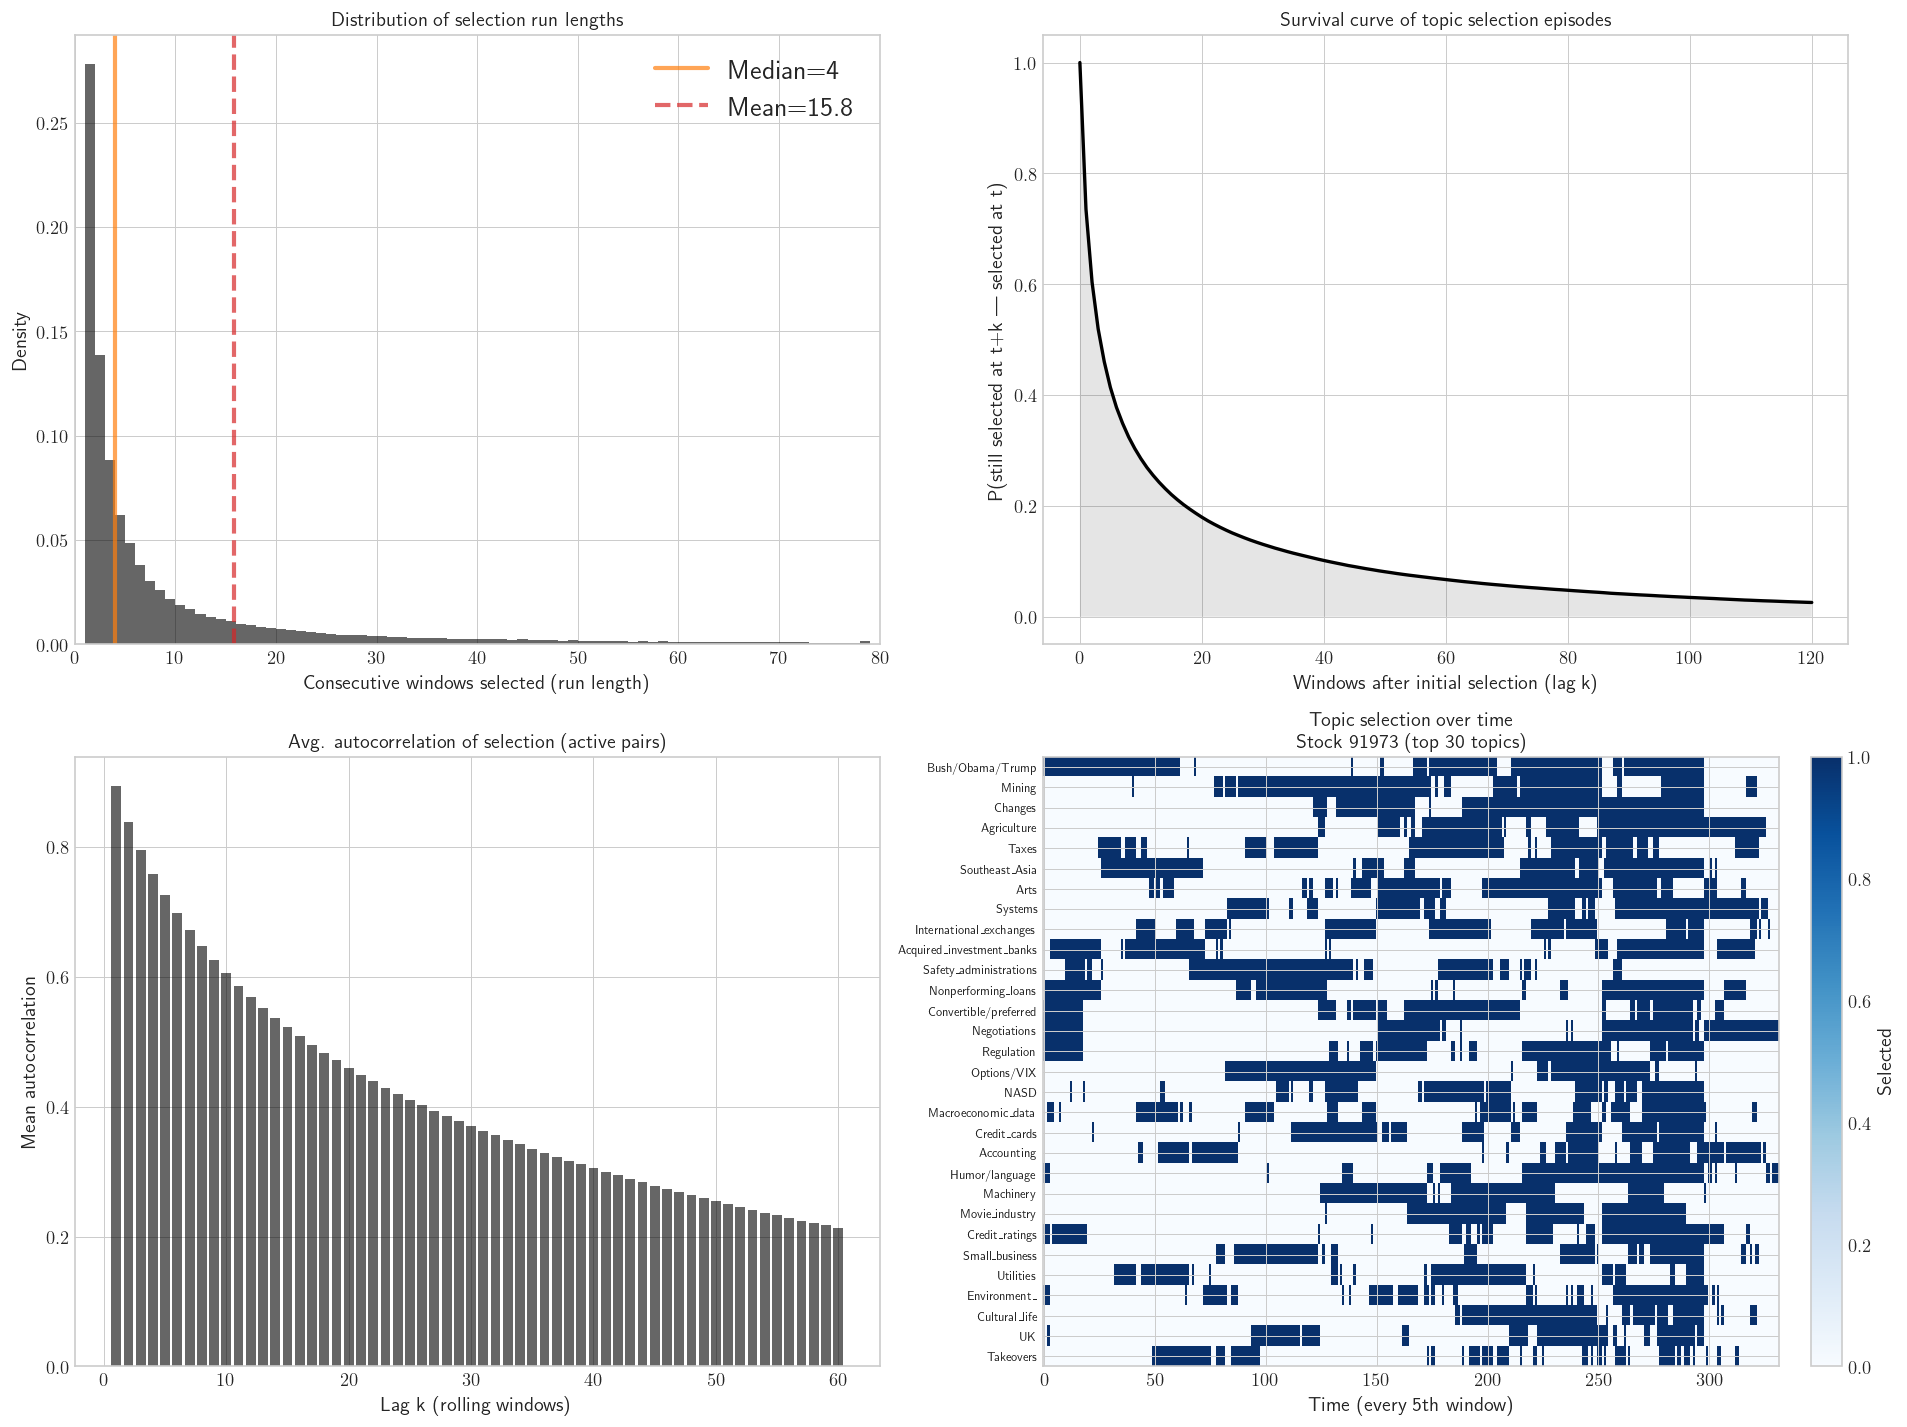

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load Stock Mapping ---
# Load the mapping from PERMNO to COMNAM (Company Name)
mapping_path = r"C:\Users\jonat\Lasso_paper\Data\data_raw\stock_names.csv"
df_mapping = pd.read_csv(mapping_path)
# Create a dictionary for fast lookup. Convert PERMNO to string to ensure safe matching
permno_to_name = dict(zip(df_mapping['PERMNO'].astype(str), df_mapping['COMNAM']))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten into (n_stocks * n_topics, n_dates) to vectorize run-length detection
is_active_2d = is_active.reshape(-1, len(dates)).astype(int)

# Identify starts and ends of selection runs using np.diff
padded = np.pad(is_active_2d, ((0, 0), (1, 1)), mode='constant', constant_values=0)
diffs = np.diff(padded, axis=1)
starts = np.where(diffs == 1)
ends = np.where(diffs == -1)
run_lengths = ends[1] - starts[1]

# --- Panel A: Distribution of selection run lengths ---
ax_rl = axes[0, 0]
ax_rl.hist(run_lengths, bins=np.arange(1, min(80, run_lengths.max() + 1)), alpha=0.6, density=True)
med_rl, mean_rl = np.median(run_lengths), np.mean(run_lengths)
ax_rl.axvline(med_rl, color='tab:orange', linestyle='-', alpha=0.7, label=f'Median={med_rl:.0f}')
ax_rl.axvline(mean_rl, color='tab:red', linestyle='--', alpha=0.7, label=f'Mean={mean_rl:.1f}')
ax_rl.set_xlim(0, 80)
ax_rl.set_title('Distribution of selection run lengths')
ax_rl.set_xlabel('Consecutive windows selected (run length)')
ax_rl.set_ylabel('Density')
ax_rl.legend()

# --- Panel B: Survival curve ---
ax_surv = axes[0, 1]
max_lag = 120
survival_counts = np.zeros(max_lag + 1)
survival_counts[0] = len(run_lengths) 
for length in run_lengths:
    survival_counts[1:min(length, max_lag + 1)] += 1
    
survival_prob = survival_counts / survival_counts[0]
ax_surv.plot(np.arange(max_lag + 1), survival_prob, lw=2)
ax_surv.fill_between(np.arange(max_lag + 1), survival_prob, alpha=0.1)
ax_surv.set_title('Survival curve of topic selection episodes')
ax_surv.set_xlabel('Windows after initial selection (lag k)')
ax_surv.set_ylabel('P(still selected at t+k | selected at t)')

# --- Panel C: Avg. autocorrelation of selection ---
ax_ac = axes[1, 0]
# Filter to active pairs (mean selection rate >= 0.5% as per paper)
mean_sel_pair = is_active_2d.mean(axis=1)
active_pairs = is_active_2d[mean_sel_pair >= 0.005]

max_ac_lag = 60
acs = []
for lag in range(1, max_ac_lag + 1):
    x = active_pairs[:, :-lag]
    y = active_pairs[:, lag:]
    x_mean = x.mean(axis=1, keepdims=True)
    y_mean = y.mean(axis=1, keepdims=True)
    
    num = ((x - x_mean) * (y - y_mean)).sum(axis=1)
    den = np.sqrt(((x - x_mean)**2).sum(axis=1) * ((y - y_mean)**2).sum(axis=1))
    
    valid = den > 0
    mean_ac = np.mean(num[valid] / den[valid])
    acs.append(mean_ac)

ax_ac.bar(range(1, max_ac_lag + 1), acs, alpha=0.6)
ax_ac.set_title('Avg. autocorrelation of selection (active pairs)')
ax_ac.set_xlabel('Lag k (rolling windows)')
ax_ac.set_ylabel('Mean autocorrelation')

# --- Panel D: Heatmap of most active stock ---
ax_hm = axes[1, 1]
stock_sel_counts = is_active.sum(axis=(1, 2))
top_stock_idx = np.argmax(stock_sel_counts)

# Extract PERMNO, map to name, and fallback to PERMNO if it's missing in the CSV
top_stock_permno = str(stocks[top_stock_idx])
top_stock_name = permno_to_name.get(top_stock_permno, top_stock_permno)

# Get top 30 topics for this specific stock
topic_sel_counts_for_stock = is_active[top_stock_idx].sum(axis=1)
top_topic_idxs = np.argsort(topic_sel_counts_for_stock)[-30:][::-1]

# Plot heatmap slicing every 5th window to align visually with paper
heatmap_data = is_active[top_stock_idx, top_topic_idxs, ::5]
cax = ax_hm.imshow(heatmap_data, aspect='auto', cmap='Blues', interpolation='none')
ax_hm.set_yticks(np.arange(30))
ax_hm.set_yticklabels([topics[i] for i in top_topic_idxs], fontsize=7)
ax_hm.set_title(f'Topic selection over time\nStock {top_stock_name} (top 30 topics)')
ax_hm.set_xlabel('Time (every 5th window)')
fig.colorbar(cax, ax=ax_hm, label='Selected', fraction=0.046, pad=0.04)

plt.tight_layout()

file_path = results_dir / "distribution_survival_autocorrelation.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

# --- Print statements confirming the text values ---
print("--- PAPER STATISTICS VERIFICATION ---")
print(f"Total selection episodes (Text: 180,586): {len(run_lengths):,}")
print(f"Median run length (Text: 4): {np.median(run_lengths):.0f}")
print(f"95th percentile run length (Text: 69): {np.percentile(run_lengths, 95):.0f}")
print(f"Maximum observed length (Text: 433): {run_lengths.max()}")
print("-" * 35)
print(f"Survival to next window / lag 1 (Text: 73%): {survival_prob[1]*100:.0f}%")
print(f"Survival to lag 5 (Text: 54%): {survival_prob[5]*100:.0f}%")
print(f"Survival to lag 20 (Text: 38%): {survival_prob[20]*100:.0f}%")
print(f"Survival to lag 60 (Text: 22%): {survival_prob[60]*100:.0f}%")
print("-" * 35)
print(f"Active stock-topic pairs (Text: 39,808): {active_pairs.shape[0]:,}")
print(f"First-order autocorrelation AC(1) (Text: 0.89): {acs[0]:.2f}")
print(f"Autocorrelation AC(5) (Text: 0.70): {acs[4]:.2f}")
print(f"Autocorrelation AC(20) (Text: 0.40): {acs[19]:.2f}")
print("-----------------------------------")

plt.show()